# 02 — Prueba interactiva del entorno PVRPEnv

Este notebook ejecuta el entorno construido en la **Fase B** (Días 4, 5 y 6) y verifica visualmente su comportamiento.

**Objetivos:**

1. Ejecutar episodios aleatorios respetando la máscara de acciones.
2. Comparar la solución generada por el entorno contra la BKS de la misma instancia.
3. Inspeccionar manualmente algunas decisiones del agente aleatorio.
4. Probar diferentes configuraciones de recompensa para entender su efecto.

**Importante**: en este notebook el "agente" es una política aleatoria (uniforme sobre acciones válidas). En el Día 11 entrenaremos un agente PPO real, pero esta línea base ya nos dice mucho sobre la dificultad del problema.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import matplotlib.pyplot as plt

from src.data.instance_loader import load_instance
from src.data.solution_loader import load_solution
from src.environment.pvrp_env import PVRPEnv
from src.environment.reward import RewardConfig
from src.utils.visualization import plot_solution

DATA_DIR = PROJECT_ROOT / "data" / "raw"
plt.rcParams["figure.dpi"] = 110

## 1. Crear el entorno e inspeccionar sus dimensiones

In [2]:
instance = load_instance(DATA_DIR / "p01.txt")
env = PVRPEnv(instance, seed=42)

print(f"Instancia: {instance}")
print(f"Dimensión del estado:   {env.observation_space.shape[0]}")
print(f"Número de acciones:     {env.action_space.n}")
print(f"  └ acción 0 = cerrar ruta")
print(f"  └ acciones 1..N = visitar cliente con índice de matriz i")

obs, info = env.reset()
print(f"\nVector de estado inicial (primeros 8 valores):\n  {obs[:8]}")

Instancia: Instance(name='p01', customers=50, horizon=2, vehicles=3, capacity=160.0)
Dimensión del estado:   204
Número de acciones:     51
  └ acción 0 = cerrar ruta
  └ acciones 1..N = visitar cliente con índice de matriz i

Vector de estado inicial (primeros 8 valores):
  [0.         1.         0.5        0.33333334 0.04375    1.
 0.16223249 1.        ]


## 2. Ejecutar un solo paso e inspeccionar el resultado

In [3]:
env.reset()
mask = env.action_masks()
print(f"Máscara al inicio:")
print(f"  - Acciones válidas: {mask.sum()}/{len(mask)}")
print(f"  - ¿Acción 'cerrar ruta' permitida? {mask[0]}")

# Visitar al primer cliente disponible
valid = np.flatnonzero(mask)
first_valid = int(valid[0])
obs, reward, terminated, truncated, info = env.step(first_valid)

print(f"\nDespués de step({first_valid}):")
print(f"  Recompensa (= -distancia): {reward:.3f}")
print(f"  Cliente visitado: {info.get('visited')}")
print(f"  Ruta en construcción: {info.get('current_route')}")
print(f"  Día actual: {info.get('day')} / {instance.horizon}")
print(f"  Vehículo actual: {info.get('vehicle')}")

Máscara al inicio:
  - Acciones válidas: 50/51
  - ¿Acción 'cerrar ruta' permitida? False

Después de step(1):
  Recompensa (= -distancia): -13.892
  Cliente visitado: 1
  Ruta en construcción: [0, 1]
  Día actual: 1 / 2
  Vehículo actual: 1


## 3. Ejecutar un episodio completo con política aleatoria

La política elige uniformemente entre las acciones permitidas por la máscara. Esto es el **baseline más simple posible**: ningún aprendizaje, ninguna heurística.

In [4]:
def run_random_episode(env, seed=0, max_steps=5000):
    env.reset(seed=seed)
    rng = np.random.default_rng(seed)
    total_reward = 0.0
    n_steps = 0
    for _ in range(max_steps):
        mask = env.action_masks()
        valid = np.flatnonzero(mask)
        action = int(rng.choice(valid))
        _, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        n_steps += 1
        if terminated or truncated:
            break
    return total_reward, n_steps, info

total_reward, n_steps, last_info = run_random_episode(env, seed=42)
sol = env.get_solution()
feasible, violations = sol.is_feasible(instance)

print(f"Episodio terminado en {n_steps} pasos")
print(f"Recompensa acumulada:   {total_reward:.2f}")
print(f"Costo total de rutas:   {sol.total_cost(instance):.2f}")
print(f"Número de rutas:        {len(sol.routes)}")
print(f"¿Solución factible?     {feasible}")
print(f"Violaciones detectadas: {len(violations)}")
if violations:
    print(f"Primeras 3 violaciones:")
    for v in violations[:3]:
        print(f"  - {v}")

Episodio terminado en 55 pasos
Recompensa acumulada:   -2183.53
Costo total de rutas:   1683.53
Número de rutas:        5
¿Solución factible?     False
Violaciones detectadas: 1
Primeras 3 violaciones:
  - Cliente 12: visitado 0 veces, se requieren 1.


### Observación esperada

La política aleatoria casi siempre produce una solución **infactible**: típicamente quedan clientes sin visitar porque la política gasta vehículos en visitas redundantes o cierra rutas demasiado pronto. Esto era lo esperable y motiva la necesidad de un agente entrenado (Días 10-13).

## 4. Comparar visualmente la solución aleatoria con la BKS

Pondremos lado a lado:

- A la izquierda: la **Best Known Solution** publicada por el NEO (costo = 524.61).
- A la derecha: la solución de la política aleatoria.

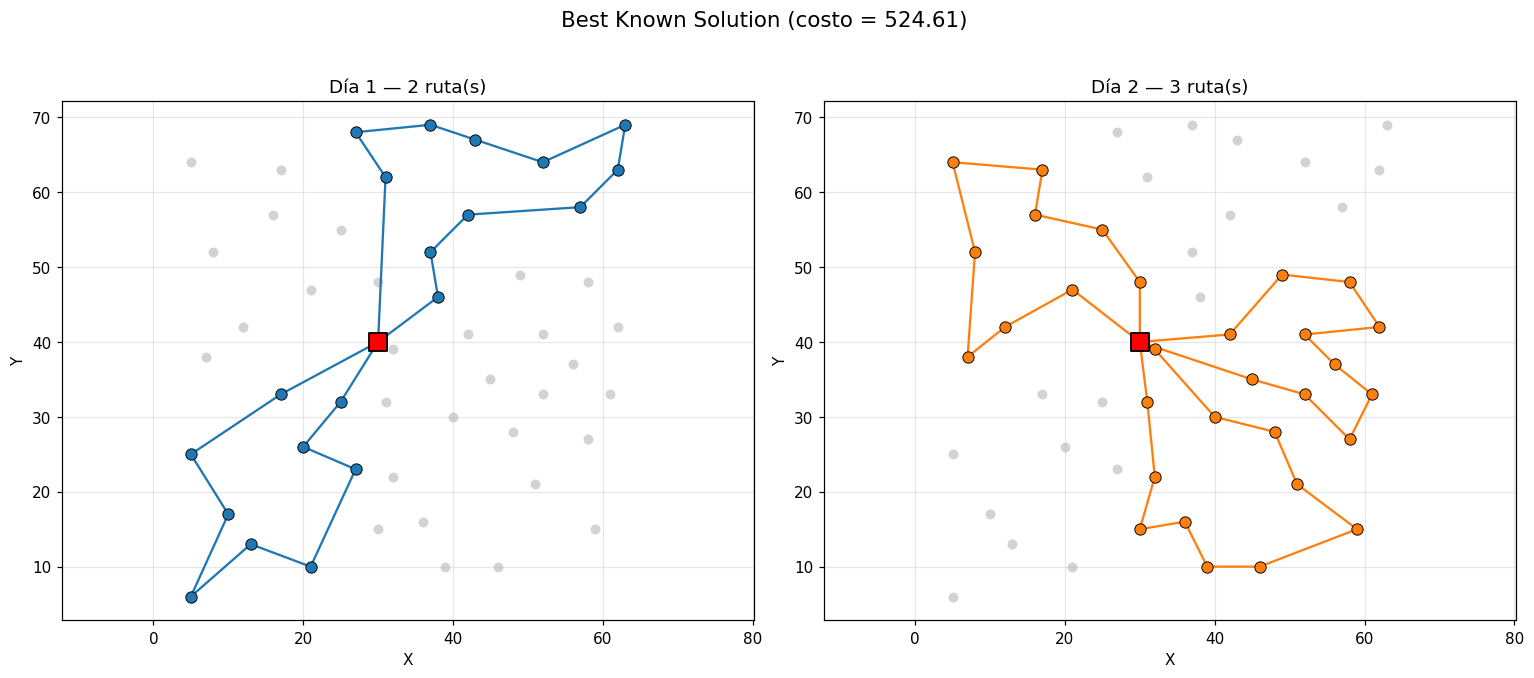

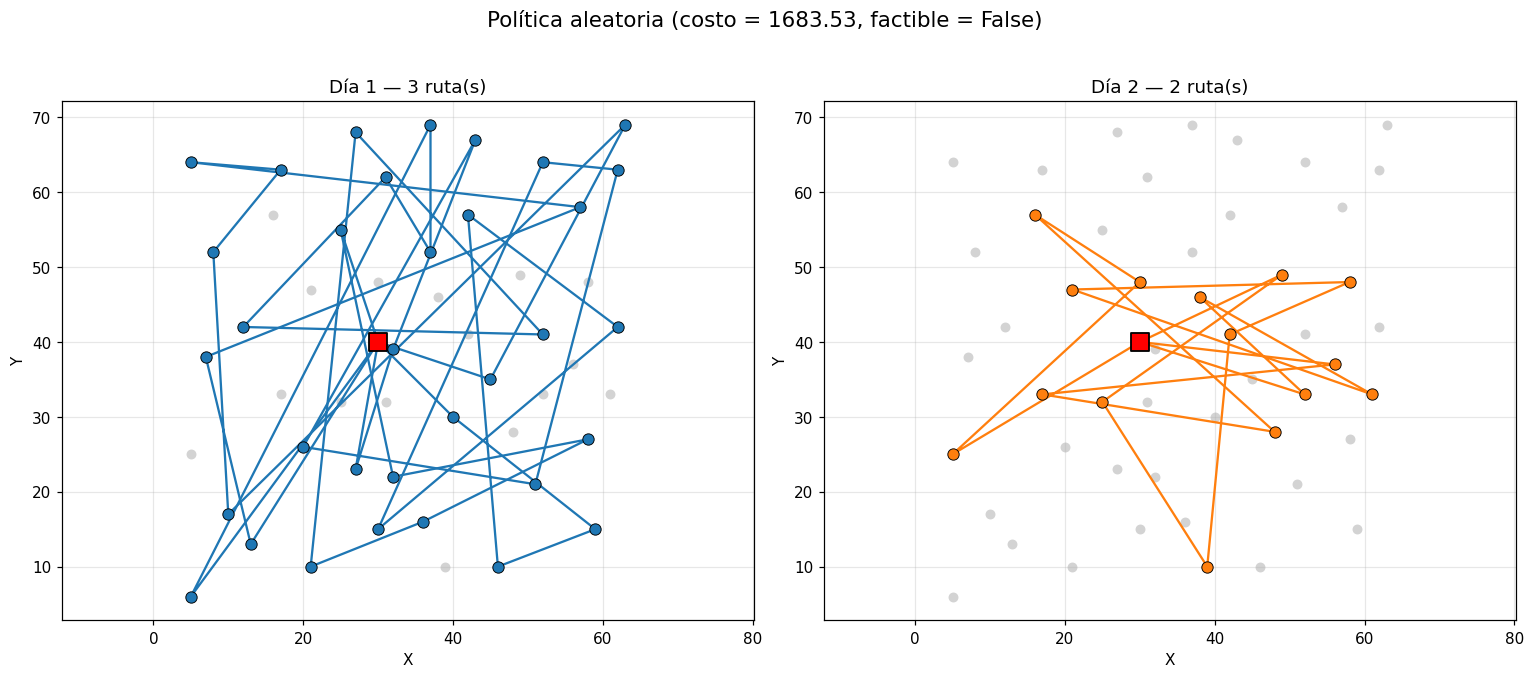

In [5]:
bks = load_solution(DATA_DIR / "p01.res")

fig_bks = plot_solution(instance, bks)
fig_bks.suptitle(f"Best Known Solution (costo = {bks.reported_cost:.2f})", fontsize=14, y=1.02)
plt.show()

fig_random = plot_solution(instance, sol)
fig_random.suptitle(
    f"Política aleatoria (costo = {sol.total_cost(instance):.2f}, "
    f"factible = {feasible})", fontsize=14, y=1.02,
)
plt.show()

## 5. Estadística sobre múltiples episodios

Ejecutamos 50 episodios con semillas distintas para obtener una distribución de costos de la política aleatoria. Esto nos da el **piso superior** contra el que comparar el agente entrenado más adelante.

In [6]:
results = []
for seed in range(50):
    env = PVRPEnv(instance, seed=seed)
    _, _, _ = run_random_episode(env, seed=seed)
    sol = env.get_solution()
    feasible, _ = sol.is_feasible(instance)
    results.append({
        "seed": seed,
        "cost": sol.total_cost(instance),
        "feasible": feasible,
        "n_routes": len(sol.routes),
    })

costs = [r["cost"] for r in results]
feasible_count = sum(1 for r in results if r["feasible"])

print(f"Episodios ejecutados:        {len(results)}")
print(f"Soluciones factibles:        {feasible_count}/{len(results)} ({feasible_count/len(results):.0%})")
print(f"Costo mínimo:                {min(costs):.2f}")
print(f"Costo máximo:                {max(costs):.2f}")
print(f"Costo promedio:              {np.mean(costs):.2f}")
print(f"BKS (referencia):            {bks.reported_cost:.2f}")
print(f"Gap promedio respecto BKS:   {(np.mean(costs) - bks.reported_cost) / bks.reported_cost * 100:.1f}%")

Episodios ejecutados:        50
Soluciones factibles:        10/50 (20%)
Costo mínimo:                1183.14
Costo máximo:                1860.43
Costo promedio:              1590.78
BKS (referencia):            524.61
Gap promedio respecto BKS:   203.2%


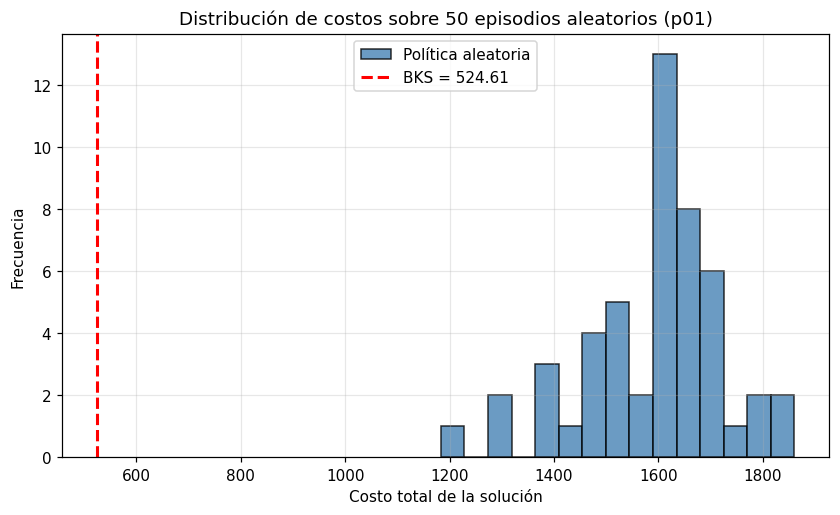

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(costs, bins=15, color="steelblue", edgecolor="black", alpha=0.8, label="Política aleatoria")
ax.axvline(bks.reported_cost, color="red", linestyle="--", linewidth=2,
           label=f"BKS = {bks.reported_cost:.2f}")
ax.set_xlabel("Costo total de la solución")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución de costos sobre 50 episodios aleatorios (p01)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

## 6. Probar diferentes configuraciones de recompensa

Comparamos tres configuraciones del bonus/penalización terminal. Esto nos dará intuición sobre cómo escalar los hiperparámetros antes del entrenamiento real (Día 10-11).

In [8]:
configs = {
    "Por defecto":   RewardConfig(terminal_bonus=100.0, infeasibility_penalty=-500.0),
    "Bonus alto":    RewardConfig(terminal_bonus=1000.0, infeasibility_penalty=-100.0),
    "Pena alta":     RewardConfig(terminal_bonus=50.0, infeasibility_penalty=-5000.0),
}

for name, cfg in configs.items():
    env = PVRPEnv(instance, reward_config=cfg, seed=42)
    total_reward, n_steps, _ = run_random_episode(env, seed=42)
    sol = env.get_solution()
    feasible, _ = sol.is_feasible(instance)
    print(f"{name:15s}: recompensa total = {total_reward:10.2f}  "
          f"costo = {sol.total_cost(instance):7.2f}  factible = {feasible}")

Por defecto    : recompensa total =   -2183.53  costo = 1683.53  factible = False
Bonus alto     : recompensa total =   -1783.53  costo = 1683.53  factible = False
Pena alta      : recompensa total =   -6683.53  costo = 1683.53  factible = False


## 7. Conclusiones de la prueba del entorno

**Verificaciones logradas:**

1. ✓ El entorno se crea, resetea y ejecuta acciones sin errores.
2. ✓ La máscara de acciones garantiza factibilidad LOCAL (capacidad, patrón) en cada paso.
3. ✓ La política aleatoria produce soluciones mayoritariamente infactibles — esto motiva la necesidad de un agente entrenado.
4. ✓ La función de recompensa responde como se espera a cambios en sus hiperparámetros.
5. ✓ El costo calculado por el entorno coincide con el costo calculado por `Solution.total_cost()`.

**Implicaciones para los próximos pasos:**

- El **Día 7** implementará la heurística Greedy, que debería producir costos significativamente mejores que la política aleatoria (vecino más cercano es una buena base).
- El **Día 8-9** agregará VNS como referencia del estado del arte.
- El **Día 10-13** entrenará el agente PPO, que debería aprender a producir soluciones consistentemente factibles y competitivas con VNS.